# 库导入

In [52]:
#  库导入
import numpy as np # 数值数学计算库
from scipy.integrate import quad # 积分计算库
from scipy import interpolate

import matplotlib.pyplot as plt # 绘图库
from matplotlib.ticker import FuncFormatter # 图表格式化库

from typing import Tuple # 类型提示库
import pandas as pd # 使用pandas读取信息

from gapp import dgp # GP拟合方法库

from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import astropy.units as u
from astropy.cosmology import z_at_value


# 全局量设置

In [53]:
# 定义全局常量
np.random.seed(202506012)
# 光速
c_light=const.c.to(u.km/u.s).value  # 定义天文学中的光速
c_mpc_yr=const.c.to(u.Mpc/u.yr) # 将光速转化为Mpc/year 的情况

# 万有引力常数
constG=const.G.to(u.Mpc**3/(u.Msun*u.s**2)).value # 是万有引力常数
constc=const.c.to(u.Mpc/u.s).value # 转换换单位为 Mpc³ / (Msun·s²)，方便天体物理和宇宙学单位下使用
 
#ACDM标准宇宙学模型=cosmo内储存了一些常量+cosmo可以计算很多宇宙学（依据其所储存的常量）量
cosmo=FlatLambdaCDM(H0=67.64,Om0=0.3087)

# 用于计算的理论函数区（计算器）

In [54]:
# 计算ACDM模型下的红移与光度距离关系
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_ACDM(H0:float=67.64, Omega_M:float=0.3087, z=None, c:float=299792.458):
        """
        计算ACDM模型下的光度距离随红移的关系
        参数:
            H0       : 哈勃常数, km/s/Mpc
            Omega_M  : 物质密度参数
            n_points : 红移点数
            c        : 光速, km/s
        返回:
            z_vals  : 红移数组, numpy.ndarray
            dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
        """
        # 定义光度距离函数
        def d_L_em(z):
            def integrand(zp):
                return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
            integral, _ = quad(integrand, 0, z)
            return (1 + z) * (c / H0) * integral

        # 向量化函数
        d_L_em_vec = np.vectorize(d_L_em)

        # 红移数组
        z_vals = np.array(z)  # 确保 z 是 numpy 数组
        dL_vals = d_L_em_vec(z_vals)
        
        ACDM_theory_data = np.column_stack((z_vals, dL_vals))
        return ACDM_theory_data 

In [55]:
# 计算RT模型下的红移与光度距离关系
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_RT(Xi:float=1.67, n:float=1.94, z=None, c:float=299792.458):
    data = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


In [56]:
# 使用内积的方法计算误差(Fisher矩阵)
# 输入：红移值 -> 输出：信噪比值
    

# 用于画图的理论函数区

In [57]:
# 计算ACDM模型下的红移与光度距离关系（平均红移点）
# 输入：(ACDM模型参数 H0, Ωm, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_ACDM(H0:float=67.64, Omega_M:float=0.3087, z_max:float=5, n_points:int=200, c:float=299792.458):
    """
    计算ACDM模型下的光度距离随红移的关系
    参数:
        H0       : 哈勃常数, km/s/Mpc
        Omega_M  : 物质密度参数
        z_max    : 红移最大值
        n_points : 红移点数
        c        : 光速, km/s
    返回:
        z_vals  : 红移数组, numpy.ndarray
        dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
    """
    # 定义光度距离函数
    def d_L_em(z):
        def integrand(zp):
            return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
        integral, _ = quad(integrand, 0, z)
        return (1 + z) * (c / H0) * integral

    # 向量化函数
    d_L_em_vec = np.vectorize(d_L_em)

    # 红移数组
    z_vals = np.linspace(0, z_max, n_points)
    dL_vals = d_L_em_vec(z_vals)
    
    ACDM_theory_data = np.column_stack((z_vals, dL_vals))
    return ACDM_theory_data 


In [58]:
# 计算RT模型下的红移与光度距离关系
# 输入：(RT模型参数 Xi, n, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_RT(Xi:float=1.67, n:float=1.94,z_max:float=5, n_points:int=200, c:float=299792.458):
    data = GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=z_max, n_points=n_points, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


# "实验"数据处理

In [59]:
#  根据参数生成此高斯函数对应的 (x,y) 数据点 这里一共是400个点
# 输入：(均值，方差) -> 输出：对应高斯函数的点(x数组[]，y数组[]) NumPy 数组
def gaussian(mu: float, sigma2: float) -> Tuple[np.ndarray, np.ndarray]:
    sigma = np.sqrt(sigma2)
    x = np.linspace(mu - 10*sigma, mu + 10*sigma, 4000) # 在中值和方差定义的范围内生成等距x值,共400个点
    y = (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(- (x - mu)**2 / (2 * sigma2))
    return x, y

In [60]:
# 根据高斯分布随机取点 从理论d_L值到实验d_L值
# 输入：(均值，方差，采样点数) -> 输出：采样点数组sample[]  NumPy 数组
def sample_from_gaussian(mu: float, sigma2: float, n_samples: int = 1) -> np.ndarray:
    if mu == 0 and sigma2 == 0:
        return np.zeros(n_samples)
    x, y = gaussian(mu, sigma2)
    y_prob = y / y.sum()  # 将高斯函数值归一化为概率[这里是离散取点]，这里的y_prob也是一个数组
    samples = np.random.choice(x, size=n_samples, p=y_prob)  # 按概率抽样
    return samples

In [61]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组

In [62]:
# 读取CSV文件，生成随机样本，并返回处理后的的数据数组 实验dL值和z值组合为数组
# 输入：二维数组[][3] -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def gaussianrandom_to_newnumpy(data:np.ndarray) -> np.ndarray:
    samples_list = []

    # 忽略第一列 z值保留
    mu_values = data[:, 1]      # 第二列    
    sigma2_values = data[:, 2]**2  # 第三列    
    for mu, sigma2 in zip(mu_values, sigma2_values):
        sample = sample_from_gaussian(mu, sigma2,1)
        samples_list.append(sample[0])  # sample 是数组，取第0个元素
    samples_array = np.array(samples_list)

    new_data = np.column_stack((data[:, 0], samples_array, data[:, 2]))
    return new_data

In [63]:
# 根据文件数据读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def ACDM_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z_values, c=299792.458)
    mu_values = data2[:,1]      # 第二列    
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [64]:
# 读取根据文件数据，读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def GT_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_RT(Xi=1.67, n=1.94, z=z_values, c=299792.458)
    mu_values = data2[:,1]     # 第二列
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [65]:
# 使用GaPP方法处理二维数组
# 输入：(二维数组data_array[][3], 以及模型参数) -> 输出：GaPP处理后的二维数组GaPP_data[][]
def gapp_solve(data:np.ndarray, xmin=0.0, xmax=10.0, nstar=200, initheta=[2.0,2.0]):
    """
    对输入数据 X,Y,Sigma 执行 Gaussian Process 重构
    
    返回：
    - Xstar: 重构函数对应横坐标
    - rec: 重构函数
    - drec: 一阶导数
    - d2rec: 二阶导数
    - d3rec: 三阶导数
    """
    X = data[:,0]
    Y = data[:,1]
    Sigma = data[:,2]

    # initialization of the Gaussian Process
    g = dgp.DGaussianProcess(X, Y, Sigma, cXstar=(xmin, xmax, nstar))

    # training of the hyperparameters and reconstruction of the function
    (rec, theta) = g.gp(theta=initheta)
    # 注意rec是重构函数的二维数组 横坐标[:,0] , 纵坐标[:,1] , 误差值[:,2]

    # reconstruction of the first, second and third derivatives.
    # theta is fixed to the previously determined value.
    (drec, theta) = g.dgp(thetatrain='False')
    (d2rec, theta) = g.d2gp()
    (d3rec, theta) = g.d3gp()
    
    # 用字典返回多个值
    result = {
        "X": X,
        "Y": Y,
        "Sigma": Sigma,
        "rec": rec,
        "drec": drec,
        "d2rec": d2rec,
        "d3rec": d3rec,
        "theta": theta
    }
    return result

# 画图区

In [66]:
# 绘制二维数组对应的理论曲线图（绘制曲线时使用）
# 输入：(二维数组data_array[..][2], 图例标签，) -> 输出：无（一个待打印的图）
def plot_line(data:np.ndarray, label:str,linecolor:str='red'):
    X = data[:,0]
    Y = data[:,1]
    plt.plot(X, Y, label=label, color=linecolor, linewidth=1.2)

In [67]:
# 绘制二维数组带error bar的散点图
# 输入：(二维数组data_array[..][3], 图例标签，点线样式，误差条颜色) -> 输出：无（一个待打印的图）
def plot_spot_with_error(data: np.ndarray, label: str = "Data", fmt: str='_', color:str='red'):
    """
    绘制带误差条的折线图（不创建新图、不调用 plt.show()，方便多次叠加）
    参数:
    - data: 二维 NumPy 数组, 每行 [x, y, error]
    - label: 图例标签
    - fmt: 点线样式
    - ecolor: 误差条颜色
    """
    x = data[:, 0]
    y = data[:, 1]
    yerr = data[:, 2]

    plt.errorbar(x, y, yerr=yerr, fmt=fmt, ecolor=color, elinewidth=0.5 ,color=color,label=label)

In [82]:
# 绘制GaPP处理后的二维数据的图
# 输入：数据字典 -> 输出：无（一个待打印的图）
def plot_gapp(result_dict: dict, color ="red",Label: str = "Reconstruction from GP"):
    X = result_dict["X"]
    Y = result_dict["Y"]
    Sigma = result_dict["Sigma"]
    rec = result_dict["rec"]
    drec = result_dict["drec"]
    d2rec = result_dict["d2rec"]
    d3rec = result_dict["d3rec"]
    
    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)
    # plt.errorbar(X, Y, Sigma, color='red', fmt='_')
    

In [101]:
# 绘制GaPP处理后的二维数据的图
# 输入：二维数组[][3] -> 输出：无（一个待打印的图）
def plot_gapp_further(rec, color ="red" ,Label: str = "Reconstruction from GP"):

    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)

    

In [70]:
# 控制生成figure的结构
def plot_show(
        xlimDOWN:float=0,xlimUP:float=0.12, 
        ylimDOWN=None, ylimUP=None,
        xlabel:str="Redshift z", ylabel:str="", 
        title:str="", zoom:float=1000.0 
):
    # plt.figure(figsize=(8,5))
    plt.xlim(xlimDOWN, xlimUP)
    
    # 设置纵轴上下限
    if ylimDOWN is not None and ylimUP is not None:
        plt.ylim(ylimDOWN, ylimUP)
    elif ylimDOWN is not None:
        plt.ylim(bottom=ylimDOWN)
    elif ylimUP is not None:
        plt.ylim(top=ylimUP)
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.1f}'))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show() 

# 运行调试区

  NIT   NF   F                       GTG
    0    1  2.211921695098185E+03   5.06831467E+07
tnc: fscale = 0.000138493
    1    7  2.131922086263369E+03   1.15633091E+05
tnc: stepmx = 1000
    2   11  7.925061413959029E+02   9.99549303E+06
    3   17  1.752825279564994E+02   2.33681648E+05
    4   19  1.725028983255939E+02   2.41440836E+02
tnc: fscale = 0.0482098
    5   21  1.724924313062856E+02   2.22891838E+02
    6   24  9.339020174864237E+01   3.89122550E+01
    7   27  8.442337561089016E+01   6.57996694E+02
    8   30  8.324331686441423E+01   7.19883539E+00
    9   36  8.320695279760531E+01   1.42820540E+01
   10   40  8.320256840525965E+01   1.62434478E+01
   11   44  8.314428514147113E+01   7.07800942E-01
tnc: fscale = 1.17686
   12   46  8.314136157499405E+01   4.46940761E-04
tnc: fscale = 46.8165
   13   48  8.314135966203827E+01   4.32904451E-08
tnc: fscale = 1602.38
   14   50  8.314133319950429E+01   6.19180421E-03
tnc: fscale = 12.5823
   15   52  8.314130677755244E+01   7


Optimized hyperparameters:
theta = [8.26915796e+02 2.86714709e-01]


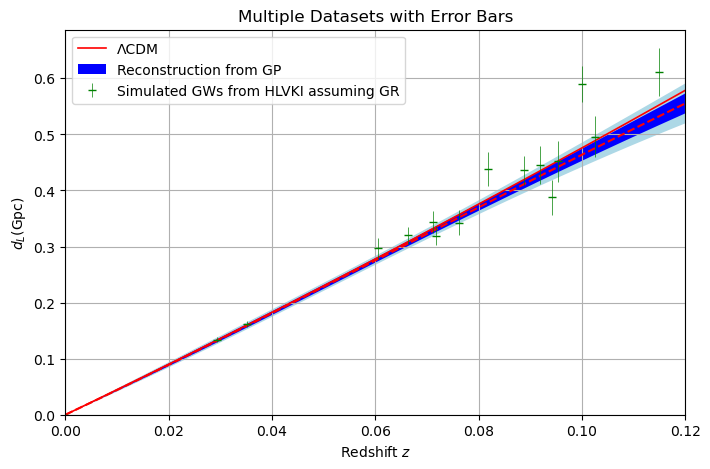

  NIT   NF   F                       GTG
    0    1  2.601349074312961E+03   6.89272912E+07
tnc: fscale = 0.000118789
    1    7  2.504095960290293E+03   5.75534134E+05
tnc: stepmx = 1000
    2   11  5.102253479014926E+02   1.12974621E+07
    3   15  2.011059044766851E+02   1.44146112E+04
tnc: fscale = 0.00816526
    4   17  2.009173447681311E+02   2.67717022E+02
    5   20  1.191753056802843E+02   1.03223261E+07
tnc: fscale = 0.00030817
    6   23  9.661186015698254E+01   3.43669220E+03
tnc: fscale = 0.0168877
    7   25  9.649354121166652E+01   1.39257152E+02
    8   27  9.647345051861200E+01   1.73521479E+02
    9   30  8.552653461530664E+01   8.69175829E+00
   10   33  8.409198424452930E+01   3.97348064E+02
   11   39  8.337253709545794E+01   2.17942779E+02
   12   43  8.293731779307441E+01   1.11312392E+02
   13   46  8.246899423082101E+01   4.73198104E+00
tnc: fscale = 0.455152
   14   48  8.245425781314009E+01   4.23861308E-03
tnc: fscale = 15.2056
   15   50  8.245424509491673E


Optimized hyperparameters:
theta = [9.93541229e+02 2.78961782e-01]


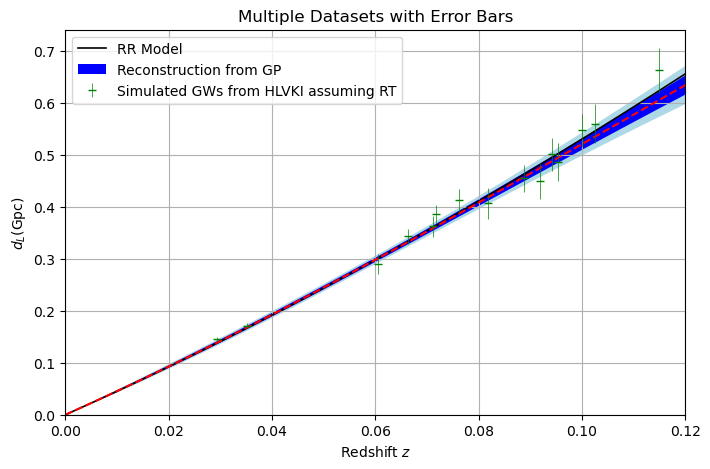

  NIT   NF   F                       GTG
    0    1  1.032413118114988E+04   1.87448155E+08
tnc: fscale = 7.2269e-05
    1    4  9.384964432251609E+03   2.12715627E+06
    2    6  7.648625484110737E+03   7.42092442E+05
    3    9  6.732152212730215E+03   8.52309120E+05
tnc: stepmx = 1000
    4   11  5.873835059222066E+03   1.26912340E+06
    5   18  1.147089107216897E+03   4.37504442E+04
tnc: fscale = 0.00465412
    6   20  1.145611322547102E+03   2.73570557E+02
    7   23  6.678289343322965E+02   7.04230433E+03
    8   27  6.099699409499459E+02   1.58857273E+04
    9   29  6.037104912198931E+02   1.33033017E+02
   10   32  5.905228076774174E+02   7.27255818E+00
tnc: fscale = 0.367141
   11   40  5.896802285047332E+02   1.74253565E-01
   12   42  5.896791693739297E+02   6.19863490E-05
tnc: fscale = 109.044
   13   44  5.896791686593606E+02   1.15708514E-05
tnc: stepmx = 100000
   14   47  5.883808227380314E+02   9.08694347E-01
tnc: fscale = 1.03865
   15   51  5.881944071253947E+02   1


Optimized hyperparameters:
theta = [6.85183373e+03 1.39806656e+00]


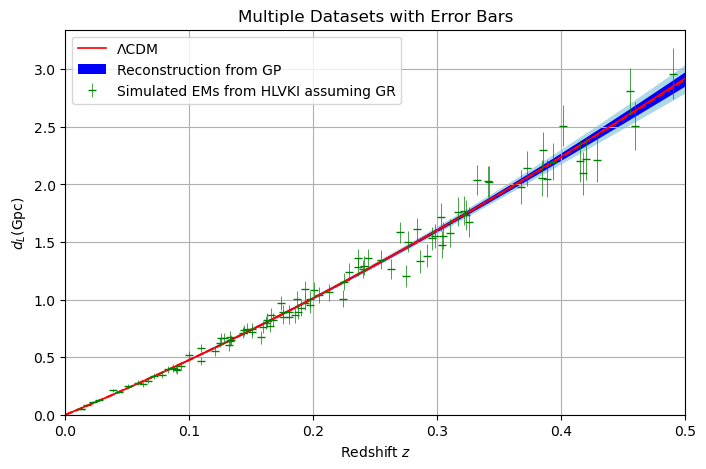

  NIT   NF   F                       GTG
    0    1  1.013187234056638E+04   1.71978675E+08
tnc: fscale = 7.54502e-05
    1    4  9.199941512136431E+03   1.52398485E+06
    2    6  7.540888375312942E+03   7.37528316E+05
    3    9  6.540961850680631E+03   1.03419082E+06
tnc: stepmx = 1000
    4   11  5.553939243853347E+03   1.67152391E+06
    5   16  1.074141400166708E+03   9.72704064E+04
tnc: fscale = 0.0031548
    6   18  1.070553231593466E+03   1.76176232E+02
    7   21  6.454823642286116E+02   1.60972974E+04
    8   24  5.728624224099472E+02   8.69009938E+02
    9   27  5.652453213204196E+02   7.52731505E+01
tnc: fscale = 0.114119
   10   29  5.649127725811696E+02   3.69416081E+00
   11   31  5.648846315874096E+02   8.61657621E-02
tnc: fscale = 3.37283
   12   33  5.648837523029671E+02   1.76997255E-04
tnc: fscale = 72.9096
   13   35  5.648837501957984E+02   1.30966723E-06
tnc: stepmx = 100000
   14   38  5.637551367804288E+02   1.58949966E+00
tnc: fscale = 0.785323
   15   42  5.


Optimized hyperparameters:
theta = [5.72091780e+03 1.28682717e+00]


  NIT   NF   F                       GTG
    0    1  2.718025669336112E+03   7.37562797E+07
tnc: fscale = 0.000114873
    1    7  2.609819140535396E+03   7.86838050E+05
tnc: stepmx = 1000
    2   11  4.592770702356864E+02   1.04518532E+07
    3   15  2.057957479891768E+02   1.33896768E+05
tnc: fscale = 0.00270231
    4   17  2.044873419284127E+02   1.96797327E+03
    5   23  1.901941922761487E+02   1.16210984E+06
    6   26  1.017671613960956E+02   7.19875587E+04
    7   29  8.240943223358025E+01   7.17706802E+03
    8   34  8.162516286866116E+01   9.02233520E+02
    9   40  8.035345808829976E+01   8.71710507E+01
tnc: fscale = 0.106043
   10   42  8.032514316514663E+01   1.36671511E-01
tnc: fscale = 2.64751
   11   44  8.032509306261051E+01   4.76545129E-04
   12   47  7.835294839245198E+01   8.97180834E+01
tnc: fscale = 0.104529
   13   49  7.819279015897168E+01   9.58025269E-01
   14   51  7.819131034074807E+01   1.36976097E-04
tnc: fscale = 84.5613
   15   53  7.819131012535649E+01 


Optimized hyperparameters:
theta = [8.26623064e+02 2.01504537e-01]


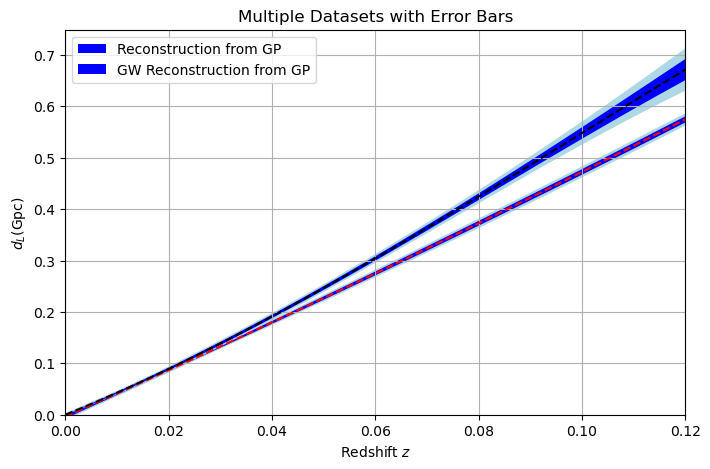

In [ ]:
plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.12, n_points=200), label='ΛCDM', linecolor='red')
plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01]), Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_RT(Xi=1.67, n=1.94, z_max=0.12, n_points=200), label='RR Model', linecolor='black')
plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01]), Label='Reconstruction from GP')
plot_spot_with_error(GT_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming RT', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.5, n_points=200), label='ΛCDM', linecolor='red')
plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.5, nstar=200, initheta=[2.0,0.01]), Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/outputEM.csv'), label='Simulated EMs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.5,ylimDOWN=0, xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5))  # 先创建 figure
plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01]), color ="red",Label='Reconstruction from GP')
plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01]),color="black", Label='GW Reconstruction from GP')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)


# 二级计算

## 计算理论比值

In [72]:
def Dz_GR(z_max,n_point):
    x = np.linspace(0,z_max,n_point)
    y = np.full_like(x, 1.0)
    Dz = np.column_stack((x,y))
    return Dz
    

In [73]:
def Dz_RT(z_max,n_point):
    x = np.linspace(0,z_max,n_point) 
    d_EM = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=x, c=c_light)
    d_GW = GW_calculate_RT(Xi=1.67, n=1.94, z=x, c=c_light)

    # 处理 0/0 的情况
    y = np.zeros_like(x)
    y[1:] = d_GW[1:,1] / d_EM[1:,1]
    y[0] = 1.0  # 理论上在z=0时应相等

    Dz = np.column_stack((x,y))
    return Dz

# Dz = Dz_RT(1.2,100)
# print(Dz[:10])

## 计算实验重构比值

In [145]:
def Dz_gapp_GR():
    GWz =gapp_solve (GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01])
    EMz = gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01])

    recGW = GWz["rec"]
    recEM = EMz["rec"]

    x1, y1, sigma1 = recGW[:,0], recGW[:,1], recGW[:,2]
    x2, y2, sigma2 = recEM[:,0], recEM[:,1], recEM[:,2]

    epsilon = 1e-12
    Dz = y1 / (y2 +epsilon)
    
    Sigma = np.sqrt( (sigma1/(y2+epsilon))**2 + (y1*sigma2/(y2+epsilon)**2)**2 )

    
    data = np.column_stack((x1,Dz,Sigma))
    print(y2)
    # print(y2)
    # print(Dz)

    return data
Dz_gapp_GR()



Optimized hyperparameters:
theta = [8.30546141e+02 2.06676328e-01]


  NIT   NF   F                       GTG
    0    1  2.617258034962707E+03   6.67785072E+07
tnc: fscale = 0.000120718
    1    7  2.513839296933123E+03   8.38222375E+05
tnc: stepmx = 1000
    2   11  3.949948353581628E+02   8.21055069E+06
    3   15  2.086845361532760E+02   3.80430964E+05
    4   17  2.048846738760228E+02   3.03122194E+03
tnc: fscale = 0.0171248
    5   19  2.048517775771494E+02   9.07460391E+01
    6   22  9.784316895031762E+01   2.24310930E+02
    7   25  8.506204191069122E+01   1.12024555E+03
    8   28  8.321806394063989E+01   9.22790573E+00
    9   32  8.319120798501848E+01   3.55284953E+01
   10   34  8.314310217229195E+01   2.74538331E+00
tnc: fscale = 0.597554
   11   36  8.313693370251821E+01   1.17729049E-03
tnc: fscale = 28.8428
   12   38  8.313693097852482E+01   1.35751865E-07
tnc: fscale = 906.074
   13   40  8.313692358042354E+01   3.20559180E-03
tnc: fscale = 17.4844
   14   42  8.313691617547619E+01   1.35531119E-07
tnc: fscale = 906.223
   15   44  8.


Optimized hyperparameters:
theta = [2.99725088e+03 8.77181851e-01]


tnc: |fn-fn-1] = 6.00467e-10 -> convergence
   22   64  5.715309750162540E+02   2.53778802E-08
tnc: Converged (|f_n-f_(n-1)| ~= 0)


[-1.16415322e-09  2.70964752e+00  5.42177327e+00  8.13637412e+00
  1.08534469e+01  1.35729886e+01  1.62949959e+01  1.90194657e+01
  2.17463949e+01  2.44757803e+01  2.72076187e+01  2.99419069e+01
  3.26786417e+01  3.54178200e+01  3.81594385e+01  4.09034941e+01
  4.36499834e+01  4.63989033e+01  4.91502506e+01  5.19040220e+01
  5.46602143e+01  5.74188242e+01  6.01798485e+01  6.29432839e+01
  6.57091271e+01  6.84773748e+01  7.12480239e+01  7.40210709e+01
  7.67965126e+01  7.95743456e+01  8.23545667e+01  8.51371726e+01
  8.79221599e+01  9.07095253e+01  9.34992654e+01  9.62913770e+01
  9.90858566e+01  1.01882701e+02  1.04681907e+02  1.07483470e+02
  1.10287388e+02  1.13093658e+02  1.15902275e+02  1.18713237e+02
  1.21526539e+02  1.24342180e+02  1.27160154e+02  1.29980459e+02
  1.32803092e+02  1.35628048e+02  1.38455325e+02  1.41284919e+02
  1.44116827e+02  1.46951044e+02  1.49787569e+02  1.52626396e+02
  1.55467523e+02  1.58310946e+02  1.61156662e+02  1.64004667e+02
  1.66854958e+02  1.69707

array([[0.00000000e+00, 1.25107466e-02, 0.00000000e+00],
       [6.03015075e-04, 8.97587686e-01, 4.71927299e-02],
       [1.20603015e-03, 8.99573788e-01, 4.66405674e-02],
       [1.80904523e-03, 9.01554142e-01, 4.60945267e-02],
       [2.41206030e-03, 9.03528701e-01, 4.55546199e-02],
       [3.01507538e-03, 9.05497419e-01, 4.50208607e-02],
       [3.61809045e-03, 9.07460253e-01, 4.44932606e-02],
       [4.22110553e-03, 9.09417155e-01, 4.39718317e-02],
       [4.82412060e-03, 9.11368082e-01, 4.34565844e-02],
       [5.42713568e-03, 9.13312989e-01, 4.29475295e-02],
       [6.03015075e-03, 9.15251830e-01, 4.24446771e-02],
       [6.63316583e-03, 9.17184560e-01, 4.19480364e-02],
       [7.23618090e-03, 9.19111136e-01, 4.14576161e-02],
       [7.83919598e-03, 9.21031513e-01, 4.09734244e-02],
       [8.44221106e-03, 9.22945646e-01, 4.04954687e-02],
       [9.04522613e-03, 9.24853491e-01, 4.00237558e-02],
       [9.64824121e-03, 9.26755004e-01, 3.95582915e-02],
       [1.02512563e-02, 9.28650

  NIT   NF   F                       GTG
    0    1  2.657461880388264E+03   7.10900033E+07
tnc: fscale = 0.000117002
    1    7  2.552259240695155E+03   2.69387534E+05
tnc: stepmx = 1000
    2   11  8.402948426818566E+02   1.42197598E+07
    3   16  2.042576359654098E+02   5.55198448E+05
    4   22  1.989119616330863E+02   7.97422466E+03
tnc: fscale = 0.0108748
    5   24  1.988371133499772E+02   4.55666465E+01
    6   27  9.364862945363630E+01   4.70964780E+02
    7   30  8.234547844450722E+01   1.40626970E+03
    8   34  8.095531010322492E+01   1.40138490E+00
tnc: fscale = 0.836372
    9   36  8.095222851481876E+01   1.26380443E-03
tnc: fscale = 27.796
   10   38  8.095222582156217E+01   6.47010067E-07
   11   44  8.078722149127850E+01   3.81872238E-01
   12   46  8.078557394263338E+01   5.88184849E-02
   13   48  8.078551829766211E+01   1.81945344E-03
   14   50  8.078551221514574E+01   1.74429948E-05
   15   52  8.078551219418588E+01   2.12366432E-09
tnc: fscale = 21485
tnc: |fn-f


Optimized hyperparameters:
theta = [6.09585611e+02 1.63049670e-01]


  NIT   NF   F                       GTG
    0    1  1.021958081111829E+04   1.06842439E+08
tnc: fscale = 9.56809e-05
    1    4  9.925220060649744E+03   3.80986786E+06
    2    7  8.914641981460052E+03   5.39949026E+06
    3   20  6.891150547093713E+03   3.86481119E+07
    4   22  6.886565841751092E+03   2.65202484E+07
tnc: stepmx = 1000
    5   25  1.725844221958512E+03   1.09879142E+07
    6   30  1.521366520652379E+03   1.20224923E+06
    7   34  9.363556018770504E+02   3.79485611E+06
    8   37  7.666537680864959E+02   1.82433822E+05
tnc: fscale = 0.00231774
    9   42  7.235590877849154E+02   4.39189768E+00
tnc: fscale = 0.159181
   10   44  7.149196953596502E+02   1.79255875E+05
tnc: fscale = 0.00233835
   11   46  7.059500797378920E+02   2.38319609E+02
tnc: fscale = 0.0611459
   12   48  7.059313462209705E+02   5.00431673E+00
   13   51  5.852659028200659E+02   5.30835227E+02
   14   54  5.747676940773600E+02   7.13552015E+01
   15   58  5.728229707628332E+02   3.18559415E+00
 


Optimized hyperparameters:
theta = [4.32278260e+03 1.02822681e+00]


tnc: |fn-fn-1] = 1.47795e-10 -> convergence
   24   84  5.726088946910265E+02   1.66530557E-13
tnc: Converged (|f_n-f_(n-1)| ~= 0)


[-2.79396772e-09  2.61391945e+00  5.23060703e+00  7.85006150e+00
  1.04722816e+01  1.30972660e+01  1.57250135e+01  1.83555228e+01
  2.09887926e+01  2.36248216e+01  2.62636085e+01  2.89051520e+01
  3.15494509e+01  3.41965037e+01  3.68463092e+01  3.94988661e+01
  4.21541729e+01  4.48122285e+01  4.74730314e+01  5.01365803e+01
  5.28028739e+01  5.54719108e+01  5.81436895e+01  6.08182089e+01
  6.34954674e+01  6.61754638e+01  6.88581966e+01  7.15436644e+01
  7.42318658e+01  7.69227995e+01  7.96164641e+01  8.23128581e+01
  8.50119800e+01  8.77138286e+01  9.04184023e+01  9.31256998e+01
  9.58357195e+01  9.85484601e+01  1.01263920e+02  1.03982098e+02
  1.06702992e+02  1.09426602e+02  1.12152925e+02  1.14881960e+02
  1.17613705e+02  1.20348160e+02  1.23085323e+02  1.25825191e+02
  1.28567764e+02  1.31313040e+02  1.34061018e+02  1.36811696e+02
  1.39565072e+02  1.42321145e+02  1.45079914e+02  1.47841377e+02
  1.50605532e+02  1.53372378e+02  1.56141913e+02  1.58914136e+02
  1.61689045e+02  1.64466

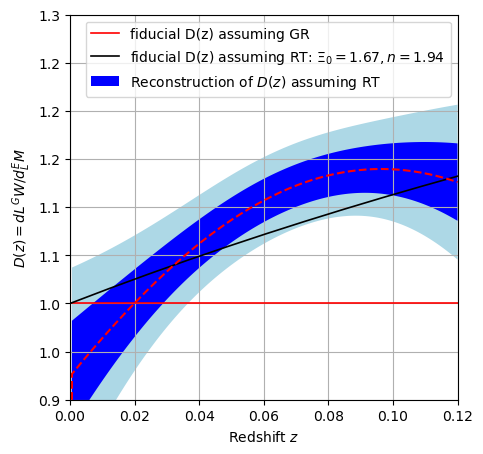

In [144]:
plt.figure(figsize=(5,5))  # 先创建 figure
plot_line(Dz_GR(1.2,100), label='fiducial D(z) assuming GR', linecolor='red')
plot_line(Dz_RT(1.2,100), label='fiducial D(z) assuming RT: $\Xi_0 =1.67, n=1.94$', linecolor='black')
plot_gapp_further(Dz_gapp_GR(), Label='Reconstruction of $D(z)$ assuming RT')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0.9, ylimUP=1.30, xlabel="Redshift $z$", ylabel="$D(z)= dL^GW / d_L^EM$",zoom=1)
